# Описание задания

Подготовить отчёт по данным о продажах магазинов Walmart

Исходные данные - таблицы:


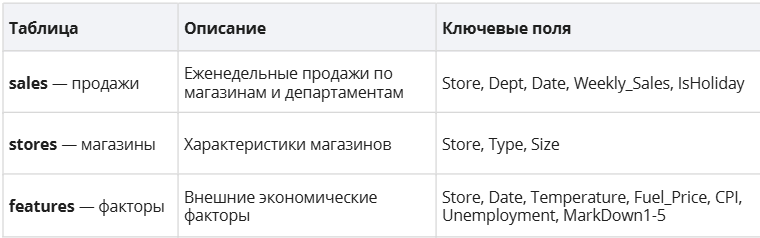

# Подготовка данных

В этом блоке происходит осмотр всех таблиц (продажи, магазины, внешние факторы), их обьединение и очистка данных

In [131]:
import pandas as pd

In [132]:
# Загрузка таблиц
df_sales = pd.read_csv("sales.csv")
df_stores = pd.read_csv("stores.csv")
df_features = pd.read_csv("features.csv")

In [133]:
df_sales.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [134]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [135]:
print(f"Всего магазинов: {df_sales["Store"].nunique()}")
print(f"Всего департаментов: {df_sales["Dept"].nunique()}")

Всего магазинов: 45
Всего департаментов: 81


In [136]:
df_stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [137]:
df_stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [138]:
# Доля типов магазинов
df_stores["Type"].value_counts(normalize=True)*100

,proportion
Type,
A,48.89
B,37.78
C,13.33


In [139]:
df_features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11,False
1,1,2010-02-12,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11,True
2,1,2010-02-19,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11,False
3,1,2010-02-26,46.63,2.56,NaN,NaN,NaN,NaN,NaN,211.32,8.11,False
4,1,2010-03-05,46.50,2.62,NaN,NaN,NaN,NaN,NaN,211.35,8.11,False


In [140]:
# Обьединение df_sales и df_stores
df_merged = pd.merge(df_sales, df_stores, on='Store', how='left')

In [141]:
# Проверка на корректное обьединение
print(f"Кол-во строк в df_sales: {df_sales.shape[0]}")
print(f"Кол-во строк в df_merged: {df_merged.shape[0]}")

Кол-во строк в df_sales: 421570
Кол-во строк в df_merged: 421570


In [142]:
df_merged.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size
0,1,1,2010-02-05,24924.50,False,A,151315
1,1,1,2010-02-12,46039.49,True,A,151315
2,1,1,2010-02-19,41595.55,False,A,151315
3,1,1,2010-02-26,19403.54,False,A,151315
4,1,1,2010-03-05,21827.90,False,A,151315


In [143]:
# Обьединение df_merged с df_features
df_full = pd.merge(df_merged, df_features, on=['Store', 'Date'], how='left', suffixes=('_sales', '_features'))

In [144]:
# Проверка на корректное обьединение
print(f"Кол-во строк в df_merged: {df_merged.shape[0]}")
print(f"Кол-во строк в df_full: {df_full.shape[0]}")

Кол-во строк в df_merged: 421570
Кол-во строк в df_full: 421570


In [145]:
# Доля пропусков в итоговой обьединенной таблице
df_full.isna().mean()*100

,0
Store,0.00
Dept,0.00
Date,0.00
Weekly_Sales,0.00
IsHoliday_sales,0.00
Type,0.00
Size,0.00
Temperature,0.00
Fuel_Price,0.00
MarkDown1,64.26


In [146]:
# Проверка дубликатов
print(f"Кол-во дубликатов: {df_full.duplicated().sum()}")

Кол-во дубликатов: 0


In [147]:
# Обработка пропусков
# В столбцах MarkDown пропущено более 50% данных, не можем использовать для анализа, поэтому удаляем эти столбцы
df_full = df_full.drop(columns=['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'])

In [148]:
df_full

,Store,Dept,Date,Weekly_Sales,IsHoliday_sales,Type,Size,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday_features
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.57,211.10,8.11,False
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.55,211.24,8.11,True
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.51,211.29,8.11,False
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.56,211.32,8.11,False
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.62,211.35,8.11,False
...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,4.00,192.01,8.68,False
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.98,192.17,8.67,False
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.00,192.33,8.67,False
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.97,192.33,8.67,False


In [150]:
# Приведение столбца Date к формату даты
df_full["Date"] = pd.to_datetime(df_full["Date"])

In [151]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Store               421570 non-null  int64         
 1   Dept                421570 non-null  int64         
 2   Date                421570 non-null  datetime64[ns]
 3   Weekly_Sales        421570 non-null  float64       
 4   IsHoliday_sales     421570 non-null  bool          
 5   Type                421570 non-null  object        
 6   Size                421570 non-null  int64         
 7   Temperature         421570 non-null  float64       
 8   Fuel_Price          421570 non-null  float64       
 9   CPI                 421570 non-null  float64       
 10  Unemployment        421570 non-null  float64       
 11  IsHoliday_features  421570 non-null  bool          
dtypes: bool(2), datetime64[ns](1), float64(5), int64(3), object(1)
memory usage: 33.0+ MB


Итоговая таблица для дальнейшей работы - **df_full**

# Анализ данных

В этом блоке - рассчет ключевых метрик и построение сводных таблиц

In [152]:
# Настройка, чтобы убрать экспоненциальную запись при больших числах
pd.options.display.float_format = '{:.2f}'.format

In [153]:
# Расчет выручки по типам магазинов
# Метрики:  общая выручка total_sales, средняя выручка на запись (avg_sales),
# кол-во записей (record_count), кол-во уникальных магазинов (store_count)
rev = (
    df_full.groupby("Type")
      .agg(
          total_sales = ("Weekly_Sales", "sum"),
          avg_sales = ("Weekly_Sales", "mean"),
          record_count = ("Weekly_Sales", "size"),
          store_count = ("Store", "nunique")
          )
      ).sort_values('total_sales', ascending=False)

rev

,total_sales,avg_sales,record_count,store_count
Type,,,,
A,4331014722.75,20099.57,215478,22
B,2000700736.82,12237.08,163495,17
C,405503527.54,9519.53,42597,6


In [154]:
# Топ-10 департаментов по выручке
rev_dept = (
    df_full.groupby("Dept", as_index=False)
      .agg(
          total_sales = ("Weekly_Sales", "sum")
      )
    )

top10_dept = rev_dept.sort_values('total_sales', ascending=False).head(10)
top10_dept

,Dept,total_sales
73,92,483943341.87
76,95,449320162.52
36,38,393118136.92
60,72,305725152.21
71,90,291068463.68
38,40,288936022.05
1,2,280611174.43
72,91,216781705.73
12,13,197321569.95
7,8,194280780.73


In [155]:
# Топ-3 департамента в каждом типе магазина
rev_dept_type = (
    df_full.groupby(['Type', 'Dept'])['Weekly_Sales'].sum()
    .reset_index()
    .sort_values(['Type', 'Weekly_Sales'], ascending=[True, False])
)

top3_dept = rev_dept_type.groupby('Type').head(3).rename(columns={'Weekly_Sales': 'total_sales'})
top3_dept

,Type,Dept,total_sales
73,A,92,352845549.71
76,A,95,305457805.93
71,A,90,221951879.82
117,B,38,141730138.72
140,B,72,127127225.80
82,B,2,104659404.51
219,C,92,52162761.54
194,C,38,46882211.29
222,C,95,43450462.66


In [156]:
# Сводная таблица - выручка по типам магазинов
# Строки - тип магазина, значения - недельные продажи
pivot_type_sales = pd.pivot_table(
    df_full,
    index="Type",
    values="Weekly_Sales",
    aggfunc="sum",
    fill_value=0
)

pivot_type_sales.round(0).rename(columns={'Weekly_Sales': 'total_sales'})

,total_sales
Type,
A,4331014723.00
B,2000700737.00
C,405503528.00


In [157]:
# Сводная таблица по типам магазинов и топ-10 департаментов по выручке
# Строки - тип магазина, столбцы - департаменты (топ-10), значения - недельные продажи
depts = top10_dept['Dept'].tolist()
df_top10 = df_full[df_full['Dept'].isin(depts)]

pivot_revenue = pd.pivot_table(
    df_top10,
    index = 'Type',
    columns='Dept',
    values="Weekly_Sales",
    aggfunc="sum",
    margins=True,
    margins_name='ИТОГО'
)

pivot_revenue

Dept,2,8,13,38,40,72,90,91,92,95,ИТОГО
Type,,,,,,,,,,,
A,163575247.15,116688981.25,117726331.69,204505786.91,168767879.76,178508245.74,221951879.82,169047601.60,352845549.71,305457805.93,1999075309.56
B,104659404.51,67044326.37,68387387.53,141730138.72,102990667.89,127127225.80,31683561.60,21458812.95,78935030.62,100411893.93,844428449.92
C,12376522.77,10547473.11,11207850.73,46882211.29,17177474.40,89680.67,37433022.26,26275291.18,52162761.54,43450462.66,257602750.61
ИТОГО,280611174.43,194280780.73,197321569.95,393118136.92,288936022.05,305725152.21,291068463.68,216781705.73,483943341.87,449320162.52,3101106510.09


# Краткий отчет



*   Магазины типа А приносят больше всего выручки, тип С - меньше всего
*   Департамент 92 лидер по выручке, далее идут 95 и 38
*   Рекомендация: оптимизировать магазины типа С





# Углубленный анализ

Гипотеза: праздничные недели приносят значительно
больше выручки, чем обычные

In [158]:
# Таблица со средней выручкой в праздничные и обычные недели
df_holiday_sales_avg = df_full.groupby('IsHoliday_sales')['Weekly_Sales'].mean()
df_holiday_sales_avg

,Weekly_Sales
IsHoliday_sales,
False,15901.45
True,17035.82


In [159]:
# Таблица с медианной выручкой в праздничные и обычные недели
df_holiday_sales_median = df_full.groupby('IsHoliday_sales')['Weekly_Sales'].median()
df_holiday_sales_median

,Weekly_Sales
IsHoliday_sales,
False,7589.95
True,7947.74


Гипотеза подтвердилась

In [161]:
# Средняя выручка по департаментам в праздники
holiday_sales = (df_full[df_full['IsHoliday_sales'] == True]
  .groupby('Dept')['Weekly_Sales']
  .mean()
  .reset_index()
)

holiday_sales = holiday_sales.rename(columns={'Weekly_Sales': 'sales'})
holiday_sales

,Dept,sales
0,1,19704.82
1,2,42203.26
2,3,12180.30
3,4,26679.60
4,5,32386.82
...,...,...
76,95,66658.30
77,96,16882.54
78,97,14004.17
79,98,7599.15


In [162]:
# Средняя выручка по департаментам в обычные дни
regular_sales = (df_full[df_full['IsHoliday_sales'] == False]
  .groupby('Dept')['Weekly_Sales']
  .mean()
  .reset_index()
)

regular_sales = regular_sales.rename(columns={'Weekly_Sales': 'sales'})
regular_sales

,Dept,sales
0,1,19176.54
1,2,43712.57
2,3,11764.63
3,4,25921.62
4,5,20538.62
...,...,...
76,95,70062.48
77,96,15085.43
78,97,14274.43
79,98,6764.64


In [164]:
# Обьединение в 1 таблицу
# департамент, Средняя выручка в праздники, Средняя выручка в обычные дни
comperison = pd.merge(holiday_sales, regular_sales, on='Dept', suffixes=['_holidays', '_regular'])
comperison

,Dept,sales_holidays,sales_regular
0,1,19704.82,19176.54
1,2,42203.26,43712.57
2,3,12180.30,11764.63
3,4,26679.60,25921.62
4,5,32386.82,20538.62
...,...,...,...
76,95,66658.30,70062.48
77,96,16882.54,15085.43
78,97,14004.17,14274.43
79,98,7599.15,6764.64


In [165]:
# Добавление столбца с пиростом
comperison['growt'] = (
    (comperison['sales_holidays'] - comperison['sales_regular'])/comperison['sales_regular'] * 100
)

In [166]:

comperison

,Dept,sales_holidays,sales_regular,growt
0,1,19704.82,19176.54,2.75
1,2,42203.26,43712.57,-3.45
2,3,12180.30,11764.63,3.53
3,4,26679.60,25921.62,2.92
4,5,32386.82,20538.62,57.69
...,...,...,...,...
76,95,66658.30,70062.48,-4.86
77,96,16882.54,15085.43,11.91
78,97,14004.17,14274.43,-1.89
79,98,7599.15,6764.64,12.34


In [168]:
# Топ-5 департаментов с наибольшим приростом выручки в праздники
top5_holiday = comperison.nlargest(5, 'growt')
top5_holiday

,Dept,sales_holidays,sales_regular,growt
80,99,1255.50,311.44,303.12
62,77,620.35,191.84,223.37
55,59,1310.37,647.22,102.46
60,72,94855.54,47217.85,100.89
5,6,7832.55,4513.90,73.52
